# Business Understanding

# Questions

1. Can you predict the average temperature, max temperature, and min temperature using machine learning?
2. What is the accuracy of linear regression?
3. What is the accuracy of Random Forest?
4. Are there differences in predictability between the three countries?
5. Accuracy of the model when predicting 1 day ahead vs 7 days ahead?

# Data Understanding

In [35]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "nordics_weather.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "adamwurdits/finland-norway-and-sweden-weather-data-20152019",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 10 records:")
print(df.head(10))

First 10 records:
   country       date  precipitation  snow_depth       tavg       tmax  \
0  Finland   1/1/2015       1.714141  284.545455   1.428571   2.912739   
1  Finland   1/2/2015      10.016667  195.000000   0.553571   2.358599   
2  Finland   1/3/2015       3.956061  284.294118  -1.739286   0.820382   
3  Finland   1/4/2015       0.246193  260.772727  -7.035714  -3.110828   
4  Finland   1/5/2015       0.036364  236.900000 -17.164286  -8.727564   
5  Finland   1/6/2015       1.212626  241.476191 -17.471429 -12.208442   
6  Finland   1/7/2015       3.486432  259.500000  -4.453571  -2.574522   
7  Finland   1/8/2015       4.208500  256.550000  -1.760714  -0.732692   
8  Finland   1/9/2015       1.923116  288.500000  -3.285714  -0.582692   
9  Finland  1/10/2015       1.515152  309.428571  -9.457143  -4.633974   

        tmin  
0  -1.015287  
1  -0.998718  
2  -3.463871  
3  -9.502581  
4 -19.004487  
5 -21.979618  
6 -14.344872  
7  -3.971338  
8  -5.239869  
9 -11.508387  


In [36]:
print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.dtypes)
print("\nBasic stats:")
print(df.describe())

Dataset shape: (5478, 7)

Dataset columns:
country           object
date              object
precipitation    float64
snow_depth       float64
tavg             float64
tmax             float64
tmin             float64
dtype: object

Basic stats:
       precipitation   snow_depth         tavg         tmax         tmin
count    5478.000000  5478.000000  5478.000000  5478.000000  5478.000000
mean        2.373517   127.252197     4.844088     8.415625     0.977423
std         2.794442   165.753504     7.802099     8.523315     7.597392
min         0.000000    -0.168539   -27.951852   -24.197403   -29.639610
25%         0.379808     0.000000    -0.810714     1.718725    -4.079661
50%         1.384036    33.234612     4.282143     7.584506     0.965888
75%         3.410252   215.604972    11.554825    15.883971     7.450520
max        21.947368   682.909091    24.407143    30.561438    17.992891


In [37]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
country          0
date             0
precipitation    0
snow_depth       0
tavg             0
tmax             0
tmin             0
dtype: int64


In [38]:
print("Unique values per column:")
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"{column}: {unique_values} unique values")

Unique values per column:
country: 3 unique values
date: 1826 unique values
precipitation: 5405 unique values
snow_depth: 3485 unique values
tavg: 4645 unique values
tmax: 5460 unique values
tmin: 5452 unique values


In [39]:
print("Duplicates in dataset:", df.duplicated().sum())

Duplicates in dataset: 0


# Data Preparation

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DAYS_AHEAD = 1

target_cols = ['tavg', 'tmax', 'tmin']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['date', 'country']).reset_index(drop=True)

df = df.dropna(subset=target_cols)

df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

LAG_DAYS = 7
for col in target_cols:
    for lag in range(1, LAG_DAYS + 1):
        df[f'{col}_lag_{lag}'] = df.groupby('country')[col].shift(lag)

for col in target_cols:
    df[f'{col}_roll7'] = df.groupby('country')[col].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
    df[f'{col}_roll14'] = df.groupby('country')[col].shift(1).rolling(14).mean().reset_index(level=0, drop=True)

for col in target_cols:
    df[f'{col}_target'] = df.groupby('country')[col].shift(-DAYS_AHEAD)

df = df.dropna().reset_index(drop=True)

feature_cols = (
    ['country_encoded', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']
    + [f'{col}_lag_{lag}' for col in target_cols for lag in range(1, LAG_DAYS + 1)]
    + [f'{col}_roll7' for col in target_cols]
    + [f'{col}_roll14' for col in target_cols]
)

X = df[feature_cols]
y = df[[f'{col}_target' for col in target_cols]]

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 4363, Test: 1091


# Modeling

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(f"Linear Regression — predicting {DAYS_AHEAD} day(s) ahead\n")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:, i], lr_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], lr_pred[:, i])
    print(f"  {col}: MAE = {mae:.2f}°C, R² = {r2:.4f}")


Linear Regression — predicting 1 day(s) ahead

  tavg: MAE = 1.93°C, R² = 0.8946
  tmax: MAE = 1.94°C, R² = 0.9145
  tmin: MAE = 2.04°C, R² = 0.8710


# Evaluation

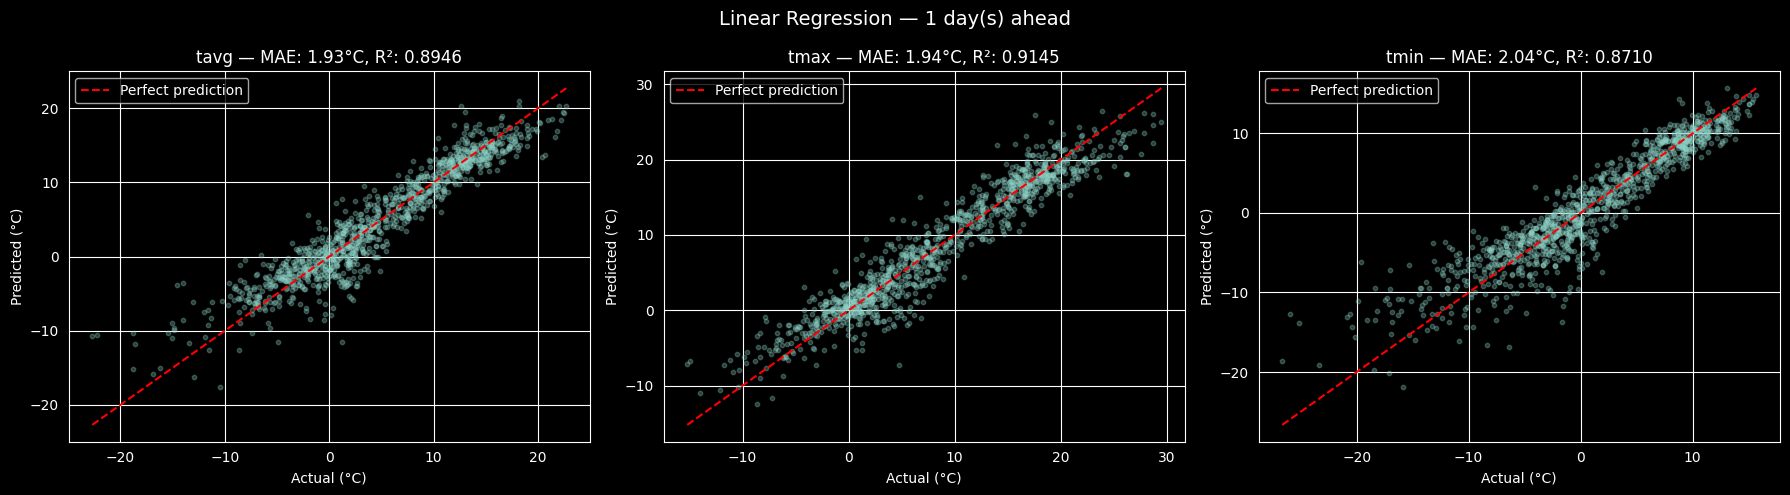

In [42]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(target_cols):
    actual = y_test.iloc[:, i].values
    predicted = lr_pred[:, i]

    axes[i].scatter(actual, predicted, alpha=0.3, s=10)
    # Perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    axes[i].set_title(f'{col} — MAE: {mae:.2f}°C, R²: {r2:.4f}')
    axes[i].set_xlabel('Actual (°C)')
    axes[i].set_ylabel('Predicted (°C)')
    axes[i].legend()

plt.suptitle(f'Linear Regression — {DAYS_AHEAD} day(s) ahead', fontsize=14)
plt.tight_layout()
plt.show()


Linear Regression per country — 1 day(s) ahead

Country    |  tavg MAE   tavg R² |  tmax MAE   tmax R² |  tmin MAE   tmin R²
-------------------------------------------------------------------------------------
Finland    |     2.48°   0.8721 |     2.23°   0.9088 |     2.52°   0.8458 |
Norway     |     1.44°   0.9239 |     1.61°   0.9172 |     1.52°   0.9079 |
Sweden     |     1.86°   0.8993 |     1.99°   0.9175 |     2.06°   0.8748 |


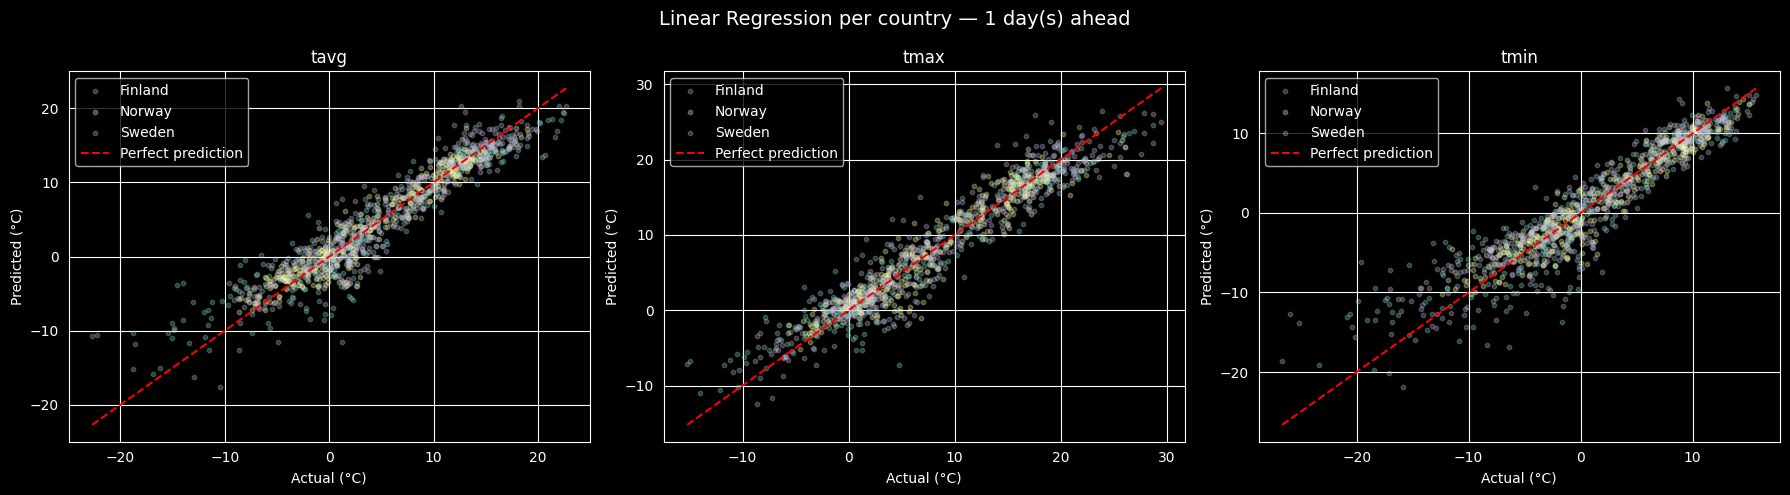

In [43]:
countries = le_country.classes_
test_countries = df.loc[y_test.index, 'country_encoded'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

print(f"Linear Regression per country — {DAYS_AHEAD} day(s) ahead\n")
print(f"{'Country':<10} | {'tavg MAE':>9} {'tavg R²':>9} | {'tmax MAE':>9} {'tmax R²':>9} | {'tmin MAE':>9} {'tmin R²':>9}")
print("-" * 85)

for c_idx, country in enumerate(countries):
    mask = test_countries == c_idx
    row = f"{country:<10} |"
    for i, col in enumerate(target_cols):
        mae = mean_absolute_error(y_test.iloc[mask, i], lr_pred[mask, i])
        r2 = r2_score(y_test.iloc[mask, i], lr_pred[mask, i])
        row += f" {mae:>8.2f}° {r2:>8.4f} |"
        axes[i].scatter(y_test.iloc[mask, i], lr_pred[mask, i], alpha=0.3, s=10, label=country)
    print(row)

for i, col in enumerate(target_cols):
    min_val = min(y_test.iloc[:, i].min(), lr_pred[:, i].min())
    max_val = max(y_test.iloc[:, i].max(), lr_pred[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    axes[i].set_title(col)
    axes[i].set_xlabel('Actual (°C)')
    axes[i].set_ylabel('Predicted (°C)')
    axes[i].legend()

plt.suptitle(f'Linear Regression per country — {DAYS_AHEAD} day(s) ahead', fontsize=14)
plt.tight_layout()
plt.show()


# Deployment